In [1]:
 # ==========================================================
# ADAPTIVE ENERGY PREDICTION SYSTEM (FINAL CLEAN - FIXED)
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

from tensorflow.keras.models import Model
from tensorflow.keras.layers import GRU, Dense, Input, Embedding, Reshape, Concatenate, RepeatVector
from tensorflow.keras.callbacks import EarlyStopping
from lightgbm.callback import early_stopping


# =========================
# CONFIG
# =========================
DATA_PATH = "sample_data/datarig40.csv"
TARGET = "energy"
SEQ_LENGTH = 48
MH_ITER = 3000
BURN_IN = 1500


# =========================
# EVALUATE (ONLY ONE VERSION)
# =========================
def evaluate(y_true, y_pred, name="Model"):
    epsilon = 1e-8

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100
    r2 = r2_score(y_true, y_pred)

    print(f"\n===== {name} =====")
    print(f"R2   : {r2:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MAPE : {mape:.2f}%")

    return {
        "RMSE": float(rmse),
        "MAE": float(mae),
        "MAPE": float(mape),
        "R2": float(r2)
    }


# =========================
# FEATURE ENGINEERING
# =========================
def feature_engineering(df):
    df = df.copy()
    df["time"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("time")

    df["hour"] = df["time"].dt.hour
    df["day_of_week"] = df["time"].dt.dayofweek

    df["hour_sin"] = np.sin((2*np.pi*df["hour"])/24)
    df["hour_cos"] = np.cos((2*np.pi*df["hour"])/24)
    df["dow_sin"] = np.sin((2*np.pi*df["day_of_week"])/7)
    df["dow_cos"] = np.cos((2*np.pi*df["day_of_week"])/7)

    df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)

    for col in ["temperature","humidity","lux"]:
        df[f"{col}_lag1"] = df[col].shift(1)
        df[f"{col}_lag24"] = df[col].shift(24)
        df[f"{col}_mean3"] = df[col].rolling(3).mean()
        df[f"{col}_mean24"] = df[col].rolling(24).mean()

    df.dropna(inplace=True)
    return df


# =========================
# LOAD DATA
# =========================
df = pd.read_csv(DATA_PATH)
df = feature_engineering(df)

n = len(df)
train_end = int(n * 0.7)
val_end   = int(n * 0.85)

train_df = df.iloc[:train_end]
val_df   = df.iloc[train_end:val_end]
test_df  = df.iloc[val_end:]


# =========================
# FEATURES
# =========================
all_features = [c for c in df.columns if c not in ["timestamp","time",TARGET]]

lgb_features = [f for f in all_features if "lag" not in f and "mean" not in f]
tegru_features = all_features


# =========================
# SCALING
# =========================
scaler_lgb = MinMaxScaler()
scaler_gru = MinMaxScaler()

X_train_lgb = scaler_lgb.fit_transform(train_df[lgb_features])
X_val_lgb   = scaler_lgb.transform(val_df[lgb_features])
X_test_lgb  = scaler_lgb.transform(test_df[lgb_features])

X_train_gru = scaler_gru.fit_transform(train_df[tegru_features])
X_val_gru   = scaler_gru.transform(val_df[tegru_features])
X_test_gru  = scaler_gru.transform(test_df[tegru_features])

y_train = train_df[TARGET].values
y_val   = val_df[TARGET].values
y_test  = test_df[TARGET].values


# =========================
# LIGHTGBM
# =========================
lgb_model = LGBMRegressor(n_estimators=1000, learning_rate=0.01)

lgb_model.fit(
    X_train_lgb, y_train,
    eval_set=[(X_val_lgb, y_val)],
    callbacks=[early_stopping(stopping_rounds=50, verbose=False)]
)

lgb_val_preds  = lgb_model.predict(X_val_lgb)
lgb_test_preds = lgb_model.predict(X_test_lgb)


# =========================
# SEQUENCE CREATION
# =========================
def create_sequences(X, y, seq_len):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i+seq_len])
        y_seq.append(y[i+seq_len])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train_gru, y_train, SEQ_LENGTH)
X_val_seq, y_val_seq     = create_sequences(X_val_gru, y_val, SEQ_LENGTH)
X_test_seq, y_test_seq   = create_sequences(X_test_gru, y_test, SEQ_LENGTH)

hour_train = train_df["hour"].values[SEQ_LENGTH:]
hour_val   = val_df["hour"].values[SEQ_LENGTH:]
hour_test  = test_df["hour"].values[SEQ_LENGTH:]


# =========================
# TEGRU
# =========================
numeric_input = Input(shape=(SEQ_LENGTH, X_train_seq.shape[2]))
hour_input = Input(shape=(1,))

hour_embed = Embedding(input_dim=24, output_dim=4)(hour_input)
hour_embed = Reshape((4,))(hour_embed)
hour_embed = RepeatVector(SEQ_LENGTH)(hour_embed)

merged = Concatenate(axis=2)([numeric_input, hour_embed])

x = GRU(64, return_sequences=True)(merged)
x = GRU(32)(x)
output = Dense(1)(x)

tegru_model = Model([numeric_input, hour_input], output)
tegru_model.compile(optimizer="adam", loss="mse")

tegru_model.fit(
    [X_train_seq, hour_train],
    y_train_seq,
    validation_data=([X_val_seq, hour_val], y_val_seq),
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)

tegru_val_preds  = tegru_model.predict([X_val_seq, hour_val]).flatten()
tegru_test_preds = tegru_model.predict([X_test_seq, hour_test]).flatten()


# =========================
# ALIGNMENT
# =========================
lgb_val_aligned  = lgb_val_preds[SEQ_LENGTH:]
lgb_test_aligned = lgb_test_preds[SEQ_LENGTH:]




[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001358 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 440
[LightGBM] [Info] Number of data points in the train set: 27983, number of used features: 12
[LightGBM] [Info] Start training from score 7.264818


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Epoch 1/100
873/873 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - loss: 34.6222 - val_loss: 29.9748
Epoch 2/100
873/873 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 24.5851 - val_loss: 18.1344
Epoch 3/100
873/873 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 15.0951 - val_loss: 11.5594
Epoch 4/100
873/873 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 10.3483 - val_loss: 7.6606
Epoch 5/100
873/873 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 7.5006 - val_loss: 6.0574
Epoch 6/100
873/873 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 6.1458 - val_loss: 5.1428
Epoch 7/100
873/873 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 5.0023 - val_loss: 7.6531
Epoch 8/100
873/873 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 4.0496 - val_loss: 3.1022
Epoch 9/100
873/873 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 3.4365 - val_loss: 2.8285
Epoch 10/100
873/873 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 3.5209 - val_loss: 2.7430
Epoch 11/100
873/873 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 2.2420 - val_loss: 2.0512
Epoch 12/100
873/873 ━━

In [2]:
# =========================
# BAYESIAN LEVEL 1
# =========================
def sigmoid(u):
    return 1 / (1 + np.exp(-u))

def hybrid_prediction(u, tegru, lgb):
    w = sigmoid(u)
    return w * tegru + (1 - w) * lgb

sigma2_lvl1 = np.var(y_val_seq - lgb_val_aligned)

def log_posterior(u):
    pred = hybrid_prediction(u, tegru_val_preds, lgb_val_aligned)
    residual = y_val_seq - pred
    return -np.sum(residual**2)/(2*sigma2_lvl1) - (u**2)/2

def metropolis():
    u = 0
    samples = []
    for _ in range(MH_ITER):
        u_new = np.random.normal(u, 0.1)
        if np.log(np.random.rand()) < log_posterior(u_new) - log_posterior(u):
            u = u_new
        samples.append(u)
    return np.array(samples)

samples_lvl1 = metropolis()
w_star_lvl1 = np.clip(np.mean(sigmoid(samples_lvl1[BURN_IN:])), 0.05, 0.95)

bayes_val_pred = w_star_lvl1 * tegru_val_preds + (1 - w_star_lvl1) * lgb_val_aligned
bayes_test_pred = w_star_lvl1 * tegru_test_preds + (1 - w_star_lvl1) * lgb_test_aligned

In [3]:
# =========================
# BAYESIAN WEIGHT (FIXED + ALIGNED)
# =========================

# Ensure consistent length (VERY IMPORTANT)
common_len = min(len(y_val_seq), len(tegru_val_preds), len(lgb_val_aligned))

Energy_true_val  = y_val_seq[:common_len]
Energy_TEGRU_val = tegru_val_preds[:common_len]
Energy_LGBM_val  = lgb_val_aligned[:common_len]


# -------------------------
# Sigmoid function
# -------------------------
def sigmoid(u):
    return 1 / (1 + np.exp(-u))


# -------------------------
# Hybrid prediction
# -------------------------
def hybrid_prediction(u, tegru_pred, lgb_pred):
    w = sigmoid(u)
    return w * tegru_pred + (1 - w) * lgb_pred


# -------------------------
# Variance (robust)
# -------------------------
sigma2 = np.var(Energy_true_val) + 1e-8


# -------------------------
# Log posterior
# -------------------------
def log_posterior(u):
    pred = hybrid_prediction(u, Energy_TEGRU_val, Energy_LGBM_val)
    residual = Energy_true_val - pred
    return -np.sum(residual**2)/(2*sigma2) - (u**2)/2


# -------------------------
# Metropolis-Hastings
# -------------------------
def metropolis_hastings(n_iter=MH_ITER, proposal_std=0.1):
    samples = []
    u = 0.0

    for _ in range(n_iter):
        u_new = np.random.normal(u, proposal_std)

        log_accept_ratio = log_posterior(u_new) - log_posterior(u)

        if np.log(np.random.rand()) < log_accept_ratio:
            u = u_new

        samples.append(u)

    return np.array(samples)


# -------------------------
# Run sampler
# -------------------------
samples = metropolis_hastings()

# Burn-in removal
weights = sigmoid(samples[BURN_IN:])

# Final weight
w_star_lvl1 = np.mean(weights)

print("\nFinal Bayesian Weight (Level 1):", w_star_lvl1)


Final Bayesian Weight (Level 1): 0.9453602680188657


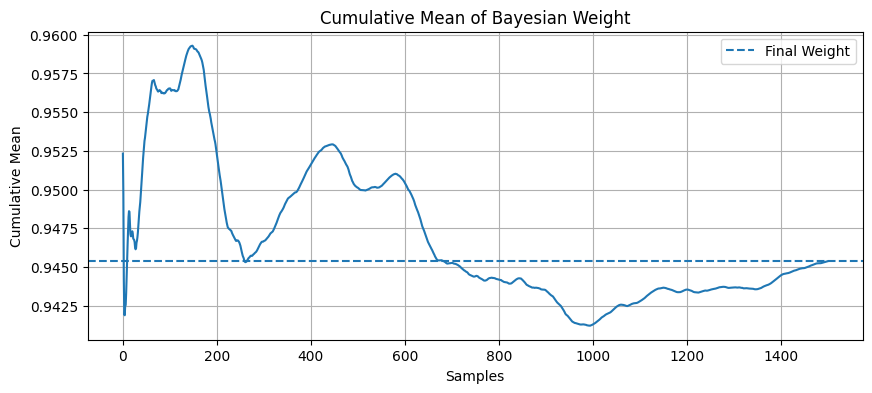

In [4]:
import numpy as np

cum_mean = np.cumsum(weights) / np.arange(1, len(weights)+1)

plt.figure(figsize=(10,4))
plt.plot(cum_mean)
plt.axhline(w_star_lvl1, linestyle='--', label="Final Weight")
plt.title("Cumulative Mean of Bayesian Weight")
plt.xlabel("Samples")
plt.ylabel("Cumulative Mean")
plt.legend()
plt.grid()
plt.show()

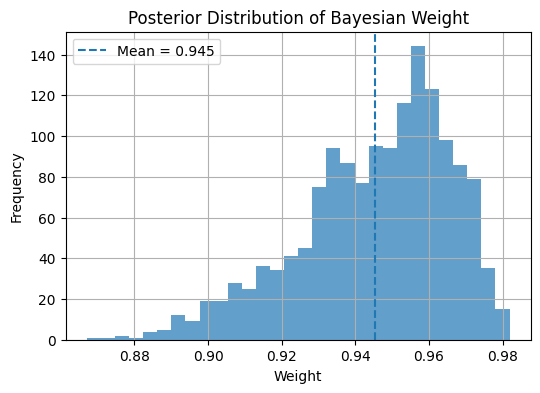

In [5]:
plt.figure(figsize=(6,4))
plt.hist(weights, bins=30, alpha=0.7)
plt.axvline(w_star_lvl1, linestyle='--', label=f"Mean = {w_star_lvl1:.3f}")
plt.title("Posterior Distribution of Bayesian Weight")
plt.xlabel("Weight")
plt.ylabel("Frequency")
plt.legend()
plt.grid()
plt.show()

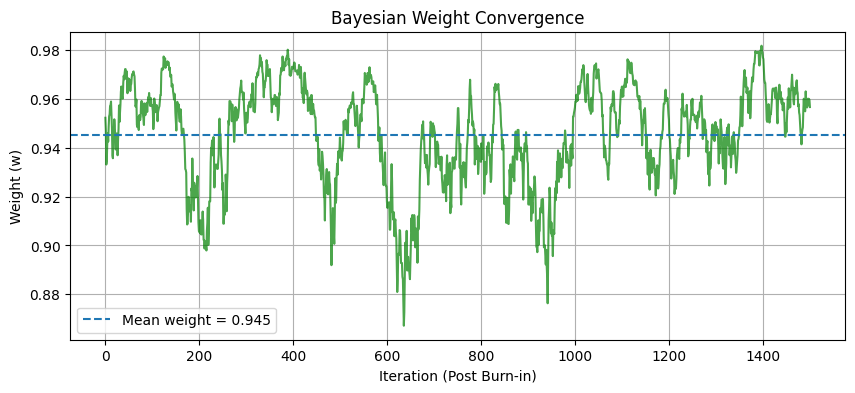

In [6]:
plt.figure(figsize=(10,4))
plt.plot(weights, color='green', alpha=0.7)
plt.axhline(w_star_lvl1, linestyle='--', label=f"Mean weight = {w_star_lvl1:.3f}")
plt.title("Bayesian Weight Convergence")
plt.xlabel("Iteration (Post Burn-in)")
plt.ylabel("Weight (w)")
plt.legend()
plt.grid()
plt.show()

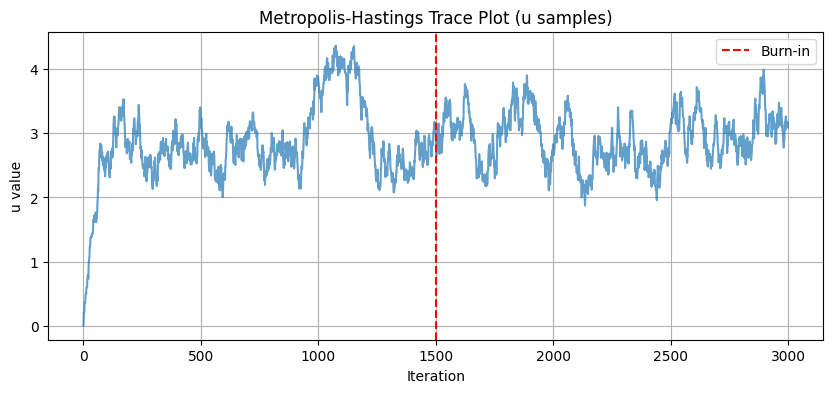

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(samples, alpha=0.7)
plt.axvline(BURN_IN, color='red', linestyle='--', label="Burn-in")
plt.title("Metropolis-Hastings Trace Plot (u samples)")
plt.xlabel("Iteration")
plt.ylabel("u value")
plt.legend()
plt.grid()
plt.show()

In [8]:
# =========================
# FINAL MODEL: XGBOOST RESIDUAL (IMPROVED VERSION)
# =========================

import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import KFold

# =========================
# STEP 1: COMPUTE RESIDUALS
# =========================

residuals_val = y_val_seq - bayes_val_pred

# =========================
# STEP 2: NOISE FILTERING (CLIPPING)
# =========================

# Clip extreme residuals to reduce noise influence
residuals_val = np.clip(residuals_val, -1, 1)

# =========================
# STEP 3: META-FEATURES
# =========================

X_residual_val = np.column_stack((
    tegru_val_preds,
    lgb_val_aligned,
    bayes_val_pred
))

# =========================
# STEP 4: REGULARIZED XGBOOST
# =========================

xgb_residual_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,          # slightly increased for stability
    max_depth=3,                # shallow trees to avoid overfitting
    subsample=0.8,              # row sampling
    colsample_bytree=0.8,       # feature sampling
    reg_lambda=5,               # L2 regularization (VERY IMPORTANT)
    reg_alpha=1,                # L1 regularization
    objective='reg:squarederror',
    random_state=42
)

# =========================
# STEP 5: CROSS-VALIDATION (ROBUST TRAINING)
# =========================

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []

for train_idx, val_idx in kf.split(X_residual_val):
    X_train_fold, X_val_fold = X_residual_val[train_idx], X_residual_val[val_idx]
    y_train_fold, y_val_fold = residuals_val[train_idx], residuals_val[val_idx]

    xgb_residual_model.fit(X_train_fold, y_train_fold)
    score = xgb_residual_model.score(X_val_fold, y_val_fold)
    cv_scores.append(score)

print("Residual Model CV R2:", np.mean(cv_scores))

# =========================
# FINAL TRAINING ON FULL VALIDATION DATA
# =========================

xgb_residual_model.fit(X_residual_val, residuals_val)

# =========================
# APPLY TO TEST
# =========================

X_residual_test = np.column_stack((
    tegru_test_preds,
    lgb_test_aligned,
    bayes_test_pred
))

# Predict residual correction
residual_pred_test = xgb_residual_model.predict(X_residual_test)

# =========================
# FINAL PREDICTION
# =========================

final_test_pred = bayes_test_pred + residual_pred_test

Residual Model CV R2: 0.17623183676802157


In [9]:
# =========================
# VALIDATION
# =========================
lgb_score = evaluate(y_val_seq, lgb_val_aligned, "LightGBM")
tegru_score = evaluate(y_val_seq, tegru_val_preds, "TEGRU")
bayes1_score = evaluate(y_val_seq, bayes_val_pred, "Bayesian Level 1")
#bayes2_score = evaluate(y_val_seq, final_val_pred, "Bayesian Level 2")

 #Validation prediction (for fair comparison)
residual_pred_val = xgb_residual_model.predict(X_residual_val)
final_val_pred = bayes_val_pred + residual_pred_val
final_score_val = evaluate(y_val_seq, final_val_pred, "XGBoost Residual (Validation)")

#=========================
# TEST
# =========================
lgb_score_test = evaluate(y_test_seq, lgb_test_aligned, "LightGBM Test")
tegru_score_test = evaluate(y_test_seq, tegru_test_preds, "TEGRU Test")
bayes1_score_test = evaluate(y_test_seq, bayes_test_pred, "Bayesian Level 1 Test")
#bayes2_score_test = evaluate(y_test_seq, final_test_pred, "Bayesian Level 2 Test")
final_score_test = evaluate(y_test_seq, final_test_pred, "XGBoost Residual (Test)")



===== LightGBM =====
R2   : 0.8950
RMSE : 2.2566
MAE  : 1.3488
MAPE : 32.57%

===== TEGRU =====
R2   : 0.9979
RMSE : 0.3183
MAE  : 0.2110
MAPE : 8.67%

===== Bayesian Level 1 =====
R2   : 0.9975
RMSE : 0.3461
MAE  : 0.2196
MAPE : 8.59%

===== XGBoost Residual (Validation) =====
R2   : 0.9980
RMSE : 0.3134
MAE  : 0.1898
MAPE : 6.46%

===== LightGBM Test =====
R2   : 0.8936
RMSE : 2.2890
MAE  : 1.3488
MAPE : 32.30%

===== TEGRU Test =====
R2   : 0.9979
RMSE : 0.3240
MAE  : 0.2135
MAPE : 8.79%

===== Bayesian Level 1 Test =====
R2   : 0.9974
RMSE : 0.3551
MAE  : 0.2227
MAPE : 8.68%

===== XGBoost Residual (Test) =====
R2   : 0.9979
RMSE : 0.3236
MAE  : 0.1938
MAPE : 6.51%



===== Final Selected Model (XGBoost Residual) =====
R2   : 0.9979
RMSE : 0.3236
MAE  : 0.1938
MAPE : 6.51%

Optimal z (calibrated): 2.5510204081632653

Adaptive Prediction Interval Coverage: 0.9438561102706338


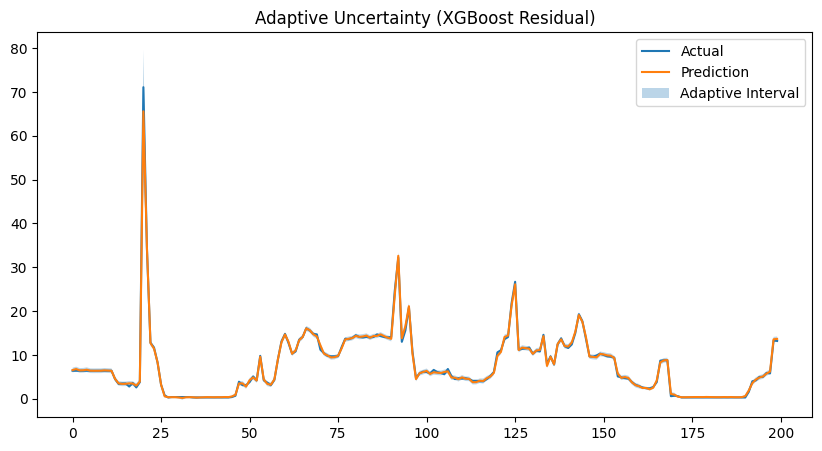


===== FINAL PREDICTIONS WITH UNCERTAINTY =====
    Actual  Predicted  Uncertainty   Lower_95   Upper_95     Error  \
0      6.4   6.556838     0.210951   6.018698   7.094977 -0.156838   
1      6.4   6.789709     0.210951   6.251569   7.327848 -0.389709   
2      6.4   6.480534     0.210951   5.942395   7.018674 -0.080534   
3      6.4   6.505860     0.210951   5.967720   7.044000 -0.105860   
4      6.4   6.639468     0.210951   6.101328   7.177608 -0.239468   
5      6.4   6.416719     0.210951   5.878579   6.954859 -0.016719   
6      6.4   6.399381     0.210951   5.861241   6.937521  0.000619   
7      6.4   6.410568     0.210951   5.872428   6.948708 -0.010568   
8      6.4   6.408647     0.210951   5.870508   6.946787 -0.008647   
9      6.4   6.493049     0.210951   5.954910   7.031189 -0.093049   
10     6.4   6.438277     0.210951   5.900137   6.976417 -0.038277   
11     6.4   6.395931     0.210951   5.857791   6.934071  0.004069   
12     4.5   4.538448     0.203312   4.019

In [12]:
# =========================
# FINAL EVALUATION
# =========================
evaluate(y_test_seq, final_test_pred, "Final Selected Model (XGBoost Residual)")


# =========================
# ADAPTIVE UNCERTAINTY MODEL
# =========================
from sklearn.ensemble import RandomForestRegressor

# Step 1: Use YOUR FINAL MODEL (from pipeline)
val_pred_selected = final_val_pred

X_val_uncertainty = np.column_stack((
    tegru_val_preds,
    lgb_val_aligned,
    bayes_val_pred
))

X_test_uncertainty = np.column_stack((
    tegru_test_preds,
    lgb_test_aligned,
    bayes_test_pred
))


# Step 2: Residuals
residuals_val = np.abs(y_val_seq - val_pred_selected)

# Step 3: Train uncertainty model
uncertainty_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

uncertainty_model.fit(X_val_uncertainty, residuals_val)

# Step 4: Predict uncertainty
predicted_uncertainty = uncertainty_model.predict(X_test_uncertainty)


# =========================
# AUTOMATIC Z CALIBRATION
# =========================
pred_uncertainty_val = uncertainty_model.predict(X_val_uncertainty)

def compute_coverage(z, y_true, y_pred, unc):
    lower = y_pred - z * unc
    upper = y_pred + z * unc
    return np.mean((y_true >= lower) & (y_true <= upper))

z_values = np.linspace(1.0, 3.0, 50)

target_coverage = 0.95
best_z = 1.96
best_diff = 1.0

for z in z_values:
    cov = compute_coverage(z, y_val_seq, val_pred_selected, pred_uncertainty_val)
    diff = abs(cov - target_coverage)

    if diff < best_diff:
        best_diff = diff
        best_z = z

z = best_z
print("\nOptimal z (calibrated):", z)


# =========================
# FINAL INTERVAL
# =========================
lower_bound = final_test_pred - z * predicted_uncertainty
upper_bound = final_test_pred + z * predicted_uncertainty

coverage = np.mean(
    (y_test_seq >= lower_bound) &
    (y_test_seq <= upper_bound)
)

print("\nAdaptive Prediction Interval Coverage:", coverage)


# =========================
# VISUALIZATION
# =========================
plt.figure(figsize=(10,5))
n = 200

plt.plot(y_test_seq[:n], label="Actual")
plt.plot(final_test_pred[:n], label="Prediction")

plt.fill_between(
    range(n),
    lower_bound[:n],
    upper_bound[:n],
    alpha=0.3,
    label="Adaptive Interval"
)

plt.legend()
plt.title("Adaptive Uncertainty (XGBoost Residual)")
plt.show()


# =========================
# FINAL RESULTS TABLE (MATCHED)
# =========================
results_df = pd.DataFrame({
    "Actual": y_test_seq,
    "Predicted": final_test_pred,
    "Uncertainty": predicted_uncertainty,
    "Lower_95": lower_bound,
    "Upper_95": upper_bound
})

results_df["Error"] = results_df["Actual"] - results_df["Predicted"]

results_df["Within_Interval"] = (
    (results_df["Actual"] >= results_df["Lower_95"]) &
    (results_df["Actual"] <= results_df["Upper_95"])
)

print("\n===== FINAL PREDICTIONS WITH UNCERTAINTY =====")
print(results_df.head(40))


# =========================
# FINAL COVERAGE (FROM TABLE)
# =========================
coverage_check = results_df["Within_Interval"].mean()
print("\nCoverage (from table):", coverage_check)